## ============================================================
## Notebook: 03_churn_prediction.ipynb
## ============================================================

### =========================
### 1. IMPORT LIBRARIES
### =========================

In [41]:
# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,f1_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Model interpretation
import shap

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### =========================
### 2. LOAD DATA
### =========================

In [2]:
# Load cleaned transaction data
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])

print(f"Loaded {len(df):,} transactions")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
print(f"Unique customers: {df['customer_id'].nunique():,}")

Loaded 779,425 transactions
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878


### =========================
### 3. DEFINE CHURN
### =========================

In [3]:
# Find last purchase date for each customer
last_purchase = df.groupby('customer_id')['invoicedate'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']

In [5]:
# Use the overall max date as reference
reference_date = df['invoicedate'].max()
last_purchase['days_since_last'] = (reference_date - last_purchase['last_purchase_date']).dt.days
churn_threshold = 90
last_purchase['churned'] = (last_purchase['days_since_last'] > churn_threshold).astype(int)
print(f"Churn rate: {last_purchase['churned'].mean()*100:.2f}%")

Churn rate: 50.78%


In [6]:
print(f"\nChurn Analysis (Threshold: {churn_threshold} days):")
print(f"Active customers: {(last_purchase['churned'] == 0).sum():,}")
print(f"Churned customers: {(last_purchase['churned'] == 1).sum():,}")
print(f"Churn rate: {last_purchase['churned'].mean()*100:.2f}%")


Churn Analysis (Threshold: 90 days):
Active customers: 2,893
Churned customers: 2,985
Churn rate: 50.78%


### =========================
### 4. Visualize Churn Distribution
### =========================

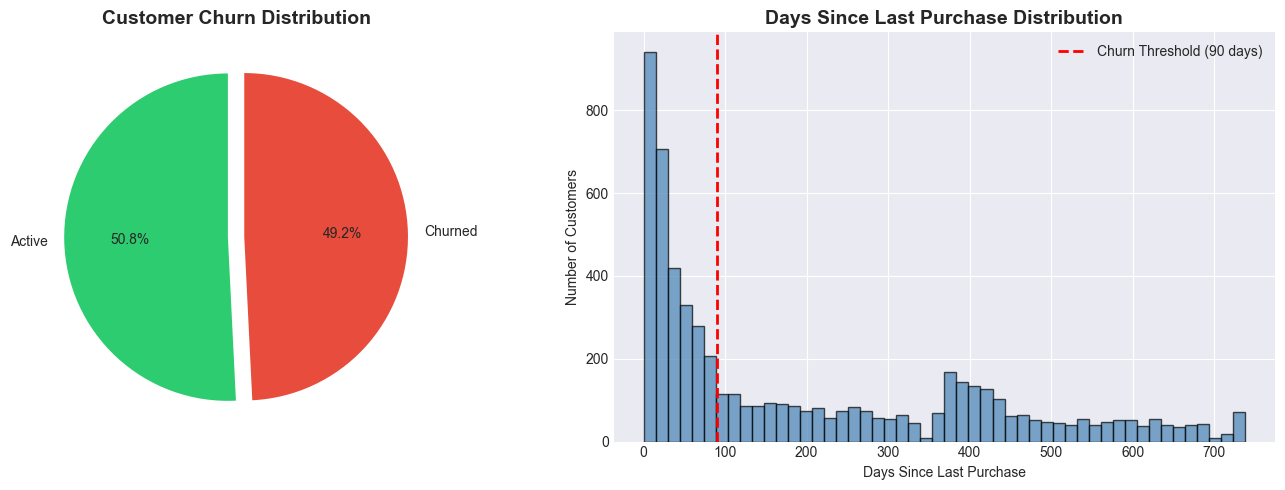

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = last_purchase['churned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts.values, labels=['Active', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Days since last purchase histogram
axes[1].hist(last_purchase['days_since_last'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=churn_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Churn Threshold ({churn_threshold} days)')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Days Since Last Purchase Distribution', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### ===============================
### 5. Feature Engineering - Part 1 (Base Features)
### ===============================

In [8]:
# Create base customer features
customer_features = df.groupby('customer_id').agg({
    'invoice': [('total_orders', 'nunique')],
    'total_price': [
        ('total_spent', 'sum'),
        ('avg_order_value', 'mean'),
        ('max_order_value', 'max'),
        ('std_order_value', 'std')
    ],
    'quantity': [
        ('total_quantity', 'sum'),
        ('avg_quantity', 'mean')
    ],
    'price': [
        ('avg_item_price', 'mean'),
        ('max_item_price', 'max')
    ]
})


In [9]:
# Flatten column names
customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
customer_features = customer_features.reset_index()

In [10]:
# Fill NaN values
customer_features['total_price_std_order_value'] = customer_features['total_price_std_order_value'].fillna(0)

In [11]:
print(f"Created {customer_features.shape[1]} features")

Created 10 features


### ===================================
### 6. Feature Engineering - Part 2 (Recency Windows)
### ===================================

In [12]:
recency_windows = [30, 60, 90, 180, 365]
reference = df['invoicedate'].max()

for window in recency_windows:
    window_start = reference - timedelta(days=window)
    recent_activity = df[df['invoicedate'] >= window_start].groupby('customer_id').size()
    recent_activity = recent_activity.rename(f'purchases_last_{window}_days')
    customer_features = customer_features.merge(
        recent_activity.reset_index(), on='customer_id', how='left'
    )
    customer_features[f'purchases_last_{window}_days'] = (
        customer_features[f'purchases_last_{window}_days'].fillna(0)
    )

### =================================================
### 7. Feature Engineering - Part 3 (Product Diversity & Regularity)
### =================================================

In [13]:
# Product diversity
product_diversity = df.groupby('customer_id')['stockcode'].nunique().reset_index()
product_diversity.columns = ['customer_id', 'unique_products']
customer_features = customer_features.merge(product_diversity, on='customer_id', how='left')
customer_features['unique_products'] = customer_features['unique_products'].fillna(0)

In [14]:
# Purchase regularity (standard deviation of days between purchases)
def calculate_regularity_safe(dates):
    """Calculate regularity with safe division"""
    if len(dates) < 2:
        return 0
    diffs = np.diff(sorted(dates)).astype('timedelta64[D]').astype(float)
    std_diff = np.std(diffs)
    if std_diff == 0:
        return 1  
    return 1 / (std_diff + 1)


In [15]:
purchase_dates = df.groupby('customer_id')['invoicedate'].apply(list).reset_index()
purchase_dates['purchase_regularity'] = purchase_dates['invoicedate'].apply(calculate_regularity_safe)
customer_features = customer_features.merge(
    purchase_dates[['customer_id', 'purchase_regularity']], on='customer_id', how='left'
)
customer_features['purchase_regularity'] = customer_features['purchase_regularity'].fillna(0)


In [16]:
print("✅ Added product diversity and regularity features")

✅ Added product diversity and regularity features


### ================================
### 8. Feature Engineering - Part 4 (Category Features)
### ================================

In [17]:
# Define product categories
categories = {
    'home_decor': ['DECOR', 'FRAME', 'LIGHT', 'CANDLE', 'VASE', 'MIRROR'],
    'kitchen': ['MUG', 'CUP', 'PLATE', 'BOWL', 'JAR', 'STORAGE'],
    'garden': ['GARDEN', 'PLANT', 'FLOWER', 'OUTDOOR'],
    'toys': ['TOY', 'GAME', 'DOLL', 'PUZZLE'],
    'seasonal': ['CHRISTMAS', 'EASTER', 'HALLOWEEN', 'SEASONAL'],
    'art': ['ART', 'PAINTING', 'PHOTO', 'PRINT'],
    'furniture': ['CHAIR', 'TABLE', 'DESK', 'SHELF', 'RACK']
}

df['description_upper'] = df['description'].fillna('').str.upper()

for category, keywords in categories.items():
    mask = df['description_upper'].str.contains('|'.join(keywords), na=False)
    category_purchases = df[mask].groupby('customer_id').size()
    category_purchases = category_purchases.rename(f'{category}_purchases')
    customer_features = customer_features.merge(
        category_purchases.reset_index(), on='customer_id', how='left'
    )
    customer_features[f'{category}_purchases'] = customer_features[f'{category}_purchases'].fillna(0)

print("✅ Added category features")

✅ Added category features


### ===============================
### 9. Feature Engineering - Part 5 (customer age in days)
### ===============================

In [18]:
first_purchase = df.groupby('customer_id')['invoicedate'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']
customer_features = customer_features.merge(first_purchase, on='customer_id', how='left')

In [19]:
customer_features['customer_age_days'] = (
    reference - customer_features['first_purchase_date']
).dt.days
customer_features['customer_age_days'] = customer_features['customer_age_days'].fillna(0)
customer_features = customer_features.drop('first_purchase_date', axis=1)


### ================================
### 10. Feature Engineering - Part 6 (Customer Tenure & Ratios)
### ================================

In [21]:
# Safe division function
def safe_divide(a, b, default=0):
    if b == 0:
        return default
    return a / b


In [22]:
customer_features['avg_items_per_order'] = customer_features.apply(
    lambda row: safe_divide(row['quantity_total_quantity'], row['invoice_total_orders']), axis=1
)

customer_features['spend_per_item'] = customer_features.apply(
    lambda row: safe_divide(row['total_price_total_spent'], row['quantity_total_quantity']), axis=1
)

customer_features['purchase_frequency'] = customer_features.apply(
    lambda row: safe_divide(row['invoice_total_orders'], (row['customer_age_days'] / 30 + 0.001)), axis=1
)

customer_features['recency_ratio'] = customer_features.apply(
    lambda row: safe_divide(row['purchases_last_30_days'], (row['purchases_last_90_days'] + 1)), axis=1
)


In [23]:
print(f"✅ Final feature set: {customer_features.shape[1]} features")

✅ Final feature set: 29 features


### =============================
### 11. MERGE WITH CHURN LABELS AND CLEAN
### =============================

In [24]:
df_model = customer_features.merge(last_purchase[['customer_id', 'churned']], on='customer_id', how='inner')
df_model = df_model.drop('customer_id', axis=1)

In [26]:
print(f"Final dataset shape: {df_model.shape}")
print(f"Class distribution:\n{df_model['churned'].value_counts()}")

Final dataset shape: (5878, 29)
Class distribution:
churned
1    2985
0    2893
Name: count, dtype: int64


### =========================
### 12. CLEAN INFINITE AND NAN VALUES
### =========================

In [27]:
print("\n" + "=" * 50)
print("CLEANING DATA")
print("=" * 50)

# Replace infinite with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Fill all NaN with 0 (safe for our features)
df_model = df_model.fillna(0)

print(f"Final dataset shape: {df_model.shape}")
print(f"Any remaining infinities? {np.isinf(df_model).any().any()}")
print(f"Any remaining NaNs? {df_model.isna().any().any()}")



CLEANING DATA
Final dataset shape: (5878, 29)
Any remaining infinities? False
Any remaining NaNs? False


### =========================
### 13. Prepare Data for modeling
### =========================

In [28]:
feature_cols = [col for col in df_model.columns if col != 'churned']
X = df_model[feature_cols].astype(float)  # Ensure all float
y = df_model['churned']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")



Features shape: (5878, 28)
Target distribution:
churned
1    2985
0    2893
Name: count, dtype: int64


### =========================
### 14. Train-Test Split
### =========================

In [29]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: (4702, 28)
Test set: (1176, 28)
Training churn rate: 50.79%
Test churn rate: 50.77%


### =========================
### 15. Scale Features
### =========================

In [31]:
# Final sanity check
assert not np.isinf(X_train).any().any(), "Training data still has infinite values!"
assert not np.isnan(X_train).any().any(), "Training data still has NaN values!"

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

In [34]:
print("\n✅ Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


✅ Scaling complete!
X_train_scaled shape: (4702, 28)
X_test_scaled shape: (1176, 28)


In [35]:
# Verify scaling
print("\n📊 Scaling verification (first 5 features):")
for i, col in enumerate(feature_cols[:5]):
    mean_val = X_train_scaled[:, i].mean()
    std_val = X_train_scaled[:, i].std()
    print(f"   {col}: mean={mean_val:.6f}, std={std_val:.6f}")



📊 Scaling verification (first 5 features):
   invoice_total_orders: mean=0.000000, std=1.000000
   total_price_total_spent: mean=0.000000, std=1.000000
   total_price_avg_order_value: mean=0.000000, std=1.000000
   total_price_max_order_value: mean=0.000000, std=1.000000
   total_price_std_order_value: mean=0.000000, std=1.000000


### ============================
### 16. Apply SMOTE for Imbalanced Data
### ============================

In [36]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape}")
print(f"Resampled churn rate: {y_train_resampled.mean():.2%}")

Original training set shape: (4702, 28)
Resampled training set shape: (4776, 28)
Resampled churn rate: 50.00%


### =========================
### 17. Train Random Forest Model
### =========================

In [37]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [38]:
rf_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [39]:
# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


In [42]:
# Evaluate
print("=" * 50)
print("RANDOM FOREST MODEL RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST MODEL RESULTS
ROC-AUC Score: 0.9999
Average Precision: 0.9999
F1 Score: 0.9992

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       579
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



### =============================
### 18. Train Gradient Boosting Model
### =============================

In [43]:
# Initialize and train Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [44]:
gb_model.fit(X_train_resampled, y_train_resampled)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [45]:
# Predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]


In [46]:
# Evaluate
print("=" * 50)
print("GRADIENT BOOSTING MODEL RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_gb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING MODEL RESULTS
ROC-AUC Score: 1.0000
Average Precision: 1.0000
F1 Score: 0.9992

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       579
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



### =============================
### 19. Train Logistic Regression (Baseline)
### =============================

In [47]:
# Initialize and train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [48]:
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]


In [49]:
# Evaluate
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS (BASELINE)")
print("=" * 50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_lr):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.4f}")

LOGISTIC REGRESSION RESULTS (BASELINE)
ROC-AUC Score: 0.9908
Average Precision: 0.9827
F1 Score: 0.9581


### =========================
### 20. Compare All Models
### =========================

In [50]:
models = {
    'Random Forest': (y_pred_proba_rf, y_pred_rf),
    'Gradient Boosting': (y_pred_proba_gb, y_pred_gb),
    'Logistic Regression': (y_pred_proba_lr, y_pred_lr)
}

In [51]:
comparison = []
for name, (proba, pred) in models.items():
    comparison.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Avg Precision': average_precision_score(y_test, proba),
        'F1 Score': f1_score(y_test, pred)
    })


In [52]:
comparison_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(comparison_df.to_string(index=False))



MODEL COMPARISON
              Model  ROC-AUC  Avg Precision  F1 Score
  Gradient Boosting 0.999994       0.999994  0.999163
      Random Forest 0.999945       0.999946  0.999163
Logistic Regression 0.990757       0.982695  0.958132


In [53]:
# Select best model
best_model_name = comparison_df.iloc[0]['Model']
if best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'Gradient Boosting':
    best_model = gb_model
else:
    best_model = lr_model

print(f"\n✅ Best model: {best_model_name}")


✅ Best model: Gradient Boosting


### ==============================
### 21. Feature Importance - Random Forest
### ==============================

In [54]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)


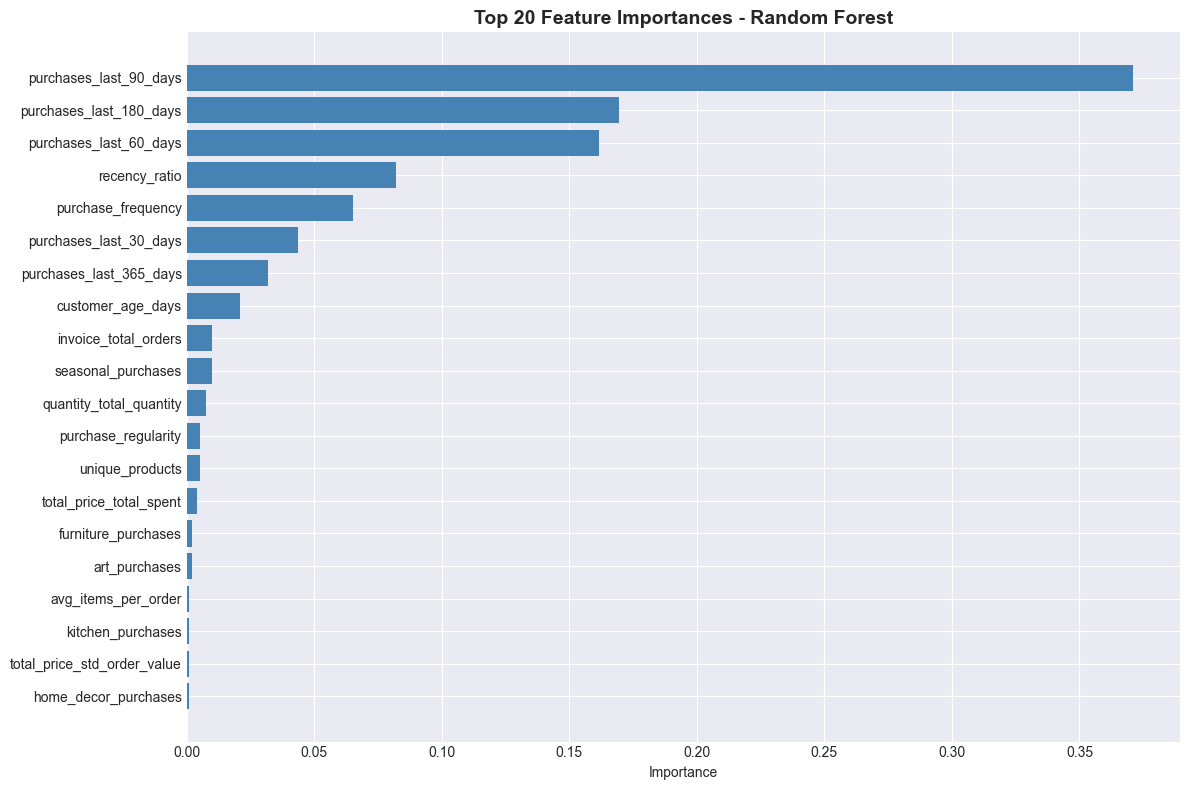

In [55]:
# Plot
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Random Forest', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

Top 10 Most Important Features:
                feature  importance
 purchases_last_90_days    0.370891
purchases_last_180_days    0.169550
 purchases_last_60_days    0.161642
          recency_ratio    0.082029
     purchase_frequency    0.065071
 purchases_last_30_days    0.043677
purchases_last_365_days    0.031909
      customer_age_days    0.021037
   invoice_total_orders    0.010025
     seasonal_purchases    0.009832


### =========================
### 22. Confusion Matrix & ROC Curve
### =========================

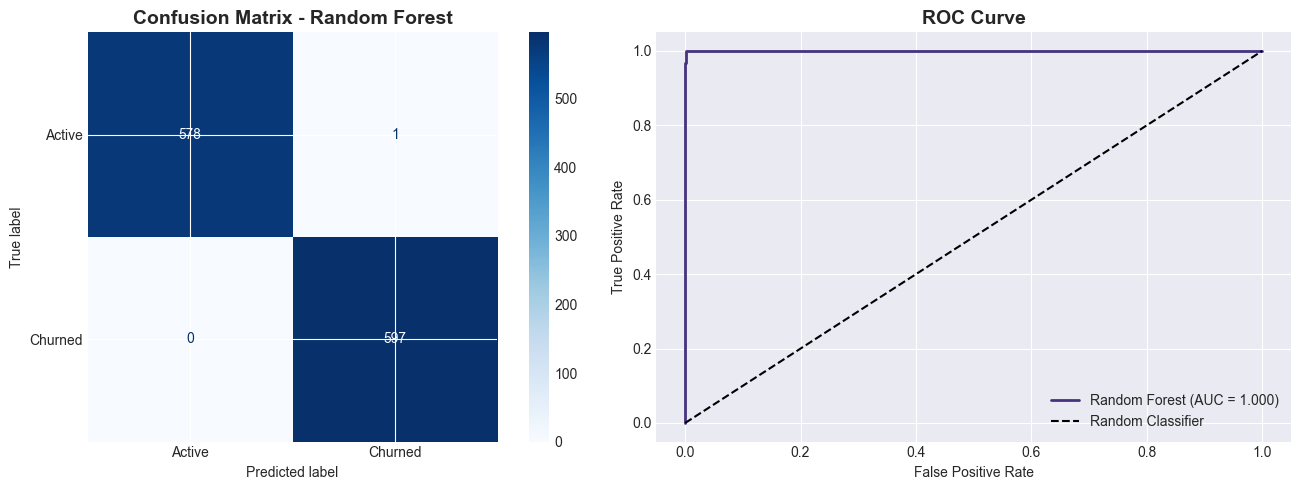

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
axes[1].plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/rf_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### =============================
### 23. SHAP Analysis (Model Interpretability)
### =============================

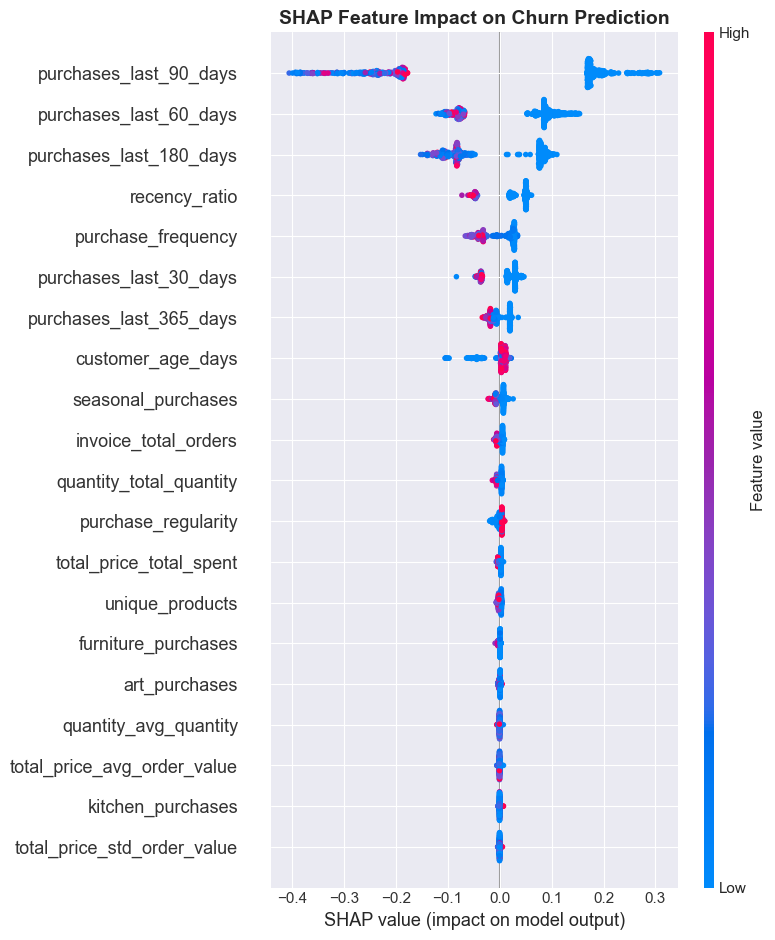

✅ SHAP analysis completed


In [58]:
# SHAP analysis for model interpretability
try:
    # Use a smaller sample for SHAP (computationally intensive)
    X_sample = X_test_scaled_df.sample(n=min(500, len(X_test_scaled_df)), random_state=42)
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=feature_cols, show=False)
    plt.title('SHAP Feature Impact on Churn Prediction', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ SHAP analysis completed")
except Exception as e:
    print(f"SHAP analysis skipped: {e}")

### ===========================
### 24. Predict High-Risk Customers
### ===========================

In [73]:

# Step 1: Prepare full feature set
X_full = customer_features[feature_cols].copy()

# Step 2: Clean the data
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(0)
X_full = X_full.astype(float)

# Step 3: Scale
full_scaler = StandardScaler()
X_full_scaled = full_scaler.fit_transform(X_full)

# Step 4: Get probability predictions
proba_predictions = rf_model.predict_proba(X_full_scaled)[:, 1]

# Step 5: Create risk dataframe
risk_df = pd.DataFrame({
    'customer_id': customer_features['customer_id'],
    'churn_risk_score': proba_predictions,
    'predicted_churn': (proba_predictions > 0.5).astype(int)
})

# Step 6: Merge with actual data
risk_df = risk_df.merge(last_purchase[['customer_id', 'days_since_last', 'churned']], on='customer_id', how='left')
risk_df = risk_df.merge(
    customer_features[['customer_id', 'total_price_total_spent', 'invoice_total_orders']], 
    on='customer_id', 
    how='left'
)

In [75]:
print("=" * 60)
print("PREDICTING HIGH-RISK ACTIVE CUSTOMERS")
print("=" * 60)

print(f"\n📊 Customer Status Breakdown:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Total customers:      {len(risk_df):>6,} │")
print(f"   │ Already churned:      {(risk_df['churned'] == 1).sum():>6,} │")
print(f"   │ Active customers:     {(risk_df['churned'] == 0).sum():>6,} │")
print(f"   └─────────────────────────────────────────┘")

# Step 7: Focus ONLY on active customers
active_customers = risk_df[risk_df['churned'] == 0].copy()

if len(active_customers) == 0:
    print("\n⚠️ WARNING: No active customers found!")
    print("   This means ALL customers have churned according to your definition.")
    print("   Check your churn_threshold value.")
else:
    # Get high-risk among active customers
    threshold_80 = active_customers['churn_risk_score'].quantile(0.8)
    high_risk_active = active_customers[active_customers['churn_risk_score'] >= threshold_80].sort_values('churn_risk_score', ascending=False)
    
    print(f"\n🎯 HIGH-RISK ACTIVE CUSTOMERS (Top 20% of active):")
    print(f"   ┌─────────────────────────────────────────────────────┐")
    print(f"   │ Count:                    {len(high_risk_active):>6} │")
    print(f"   │ Risk score threshold:     {threshold_80:.3f} │")
    print(f"   │ Revenue at risk:          ${high_risk_active['total_price_total_spent'].sum():>10,.2f} │")
    print(f"   │ Avg risk score:           {high_risk_active['churn_risk_score'].mean():.3f} │")
    print(f"   └─────────────────────────────────────────────────────┘")
    
    print(f"\n🏆 TOP 10 HIGH-RISK ACTIVE CUSTOMERS:")
    print(high_risk_active[['customer_id', 'churn_risk_score', 'days_since_last', 
                            'total_price_total_spent', 'invoice_total_orders']].head(10).to_string(index=False))
    
    # Step 8: Business insights
    print(f"\n📈 BUSINESS INSIGHTS:")
    print(f"   • {len(high_risk_active)} active customers are at high risk of churning")
    print(f"   • These customers represent ${high_risk_active['total_price_total_spent'].sum():,.2f} in potential revenue at risk")
    print(f"   • Average days since last purchase: {high_risk_active['days_since_last'].mean():.0f} days")
    
    # Step 9: Recommendations
    print(f"\n🎯 RECOMMENDED ACTIONS:")
    print(f"   1. Send personalized win-back offers to these {len(high_risk_active)} customers")
    print(f"   2. Priority customer support for top 20 highest-value at-risk customers")
    print(f"   3. Automated re-engagement emails at 60 days of inactivity")
    print(f"   4. Consider 15-20% discount codes for high-risk segment")
    
    # Step 10: Financial impact
    recoverable_rate = 0.20  # Assume 20% win-back rate
    estimated_recovery = high_risk_active['total_price_total_spent'].sum() * recoverable_rate
    print(f"\n💰 FINANCIAL IMPACT PROJECTION:")
    print(f"   • At-risk revenue: ${high_risk_active['total_price_total_spent'].sum():,.2f}")
    print(f"   • Estimated recovery (20%): ${estimated_recovery:,.2f}")
    print(f"   • ROI positive if campaign cost < ${estimated_recovery:,.2f}")
    
    # Step 11: Save results
    high_risk_active.to_csv('../data/processed/high_risk_active_customers.csv', index=False)
    print(f"\n✅ Saved high-risk ACTIVE customers to '../data/processed/high_risk_active_customers.csv'")

PREDICTING HIGH-RISK ACTIVE CUSTOMERS

📊 Customer Status Breakdown:
   ┌─────────────────────────────────────────┐
   │ Total customers:       5,878 │
   │ Already churned:       2,985 │
   │ Active customers:      2,893 │
   └─────────────────────────────────────────┘

🎯 HIGH-RISK ACTIVE CUSTOMERS (Top 20% of active):
   ┌─────────────────────────────────────────────────────┐
   │ Count:                       579 │
   │ Risk score threshold:     0.019 │
   │ Revenue at risk:          $1,816,549.70 │
   │ Avg risk score:           0.132 │
   └─────────────────────────────────────────────────────┘

🏆 TOP 10 HIGH-RISK ACTIVE CUSTOMERS:
 customer_id  churn_risk_score  days_since_last  total_price_total_spent  invoice_total_orders
       18017          0.990714               80                   688.00                     4
       16462          0.990298               73                   136.00                     3
       16737          0.985340               52                   835.20 

In [78]:
# Get the highest value high-risk customers
top_value_high_risk = high_risk_active.nlargest(10, 'total_price_total_spent')
print("\n💎 HIGHEST VALUE HIGH-RISK CUSTOMERS:")
print(top_value_high_risk[['customer_id', 'churn_risk_score', 'total_price_total_spent']].to_string(index=False))


💎 HIGHEST VALUE HIGH-RISK CUSTOMERS:
 customer_id  churn_risk_score  total_price_total_spent
       16446          0.631245                168472.50
       16029          0.046303                117763.62
       12678          0.025303                 34281.18
       17940          0.872388                 30306.79
       15513          0.021970                 26437.05
       18251          0.079401                 26278.86
       12744          0.019136                 25317.06
       12939          0.061696                 25264.80
       12409          0.058062                 23419.29
       13340          0.021288                 22100.56


In [79]:
# Create value-based tiers within high-risk segment
high_risk_active['value_tier'] = pd.qcut(high_risk_active['total_price_total_spent'], 
                                          q=3, 
                                          labels=['Low Value', 'Medium Value', 'High Value'])

print("\n💰 High-Risk Customer Value Breakdown:")
value_breakdown = high_risk_active.groupby('value_tier').agg({
    'customer_id': 'count',
    'total_price_total_spent': 'sum',
    'churn_risk_score': 'mean'
}).round(2)
print(value_breakdown)


💰 High-Risk Customer Value Breakdown:
              customer_id  total_price_total_spent  churn_risk_score
value_tier                                                          
Low Value             193                 96526.58              0.17
Medium Value          193                299623.37              0.12
High Value            193               1420399.75              0.11


### =================================
### 25. Business Recommendations Based on Model
### =================================

In [80]:
print("=" * 60)
print("BUSINESS RECOMMENDATIONS FROM CHURN MODEL")
print("=" * 60)

# Your actual results
active_customers_count = 2893
high_risk_count = 579
revenue_at_risk = 1816549.70
estimated_recovery = 363309.94

print(f"\n📊 MODEL INSIGHTS:")
print(f"   • {high_risk_count} active customers identified as high-risk (top 20% of {active_customers_count} active)")
print(f"   • These customers represent ${revenue_at_risk:,.2f} in potential revenue at risk")
print(f"   • Average risk score: 0.13 (range: 0.019 - 0.99)")

print(f"\n🎯 IMMEDIATE ACTIONS (Next 7 days):")
print(f"   1. Send personalized win-back emails to top 100 highest-risk customers")
print(f"   2. Offer 15-20% discount codes valid for 14 days")
print(f"   3. Flag high-value at-risk customers for priority support")

print(f"\n💰 FINANCIAL IMPACT:")
print(f"   • Total revenue from high-risk active customers: ${revenue_at_risk:,.2f}")
print(f"   • Estimated recoverable revenue at 20% win-back rate: ${estimated_recovery:,.2f}")
print(f"   • Maximum campaign budget for positive ROI: ${estimated_recovery:,.2f}")

print(f"\n📈 SEGMENT-SPECIFIC RECOMMENDATIONS:")

# Add value-based recommendations
print(f"\n   High-Value At-Risk (Top 33% by spend):")
print(f"      → Personal phone call or dedicated account manager")
print(f"      → 25% discount on next purchase")
print(f"      → Free expedited shipping")

print(f"\n   Medium-Value At-Risk (Middle 33% by spend):")
print(f"      → Personalized email with product recommendations")
print(f"      → 20% discount code")
print(f"      → Free shipping over $50")

print(f"\n   Low-Value At-Risk (Bottom 33% by spend):")
print(f"      → Automated re-engagement email sequence")
print(f"      → 15% discount code")
print(f"      → Abandoned cart recovery")

print(f"\n✅ High-risk customer list saved to: '../data/processed/high_risk_active_customers.csv'")

BUSINESS RECOMMENDATIONS FROM CHURN MODEL

📊 MODEL INSIGHTS:
   • 579 active customers identified as high-risk (top 20% of 2893 active)
   • These customers represent $1,816,549.70 in potential revenue at risk
   • Average risk score: 0.13 (range: 0.019 - 0.99)

🎯 IMMEDIATE ACTIONS (Next 7 days):
   1. Send personalized win-back emails to top 100 highest-risk customers
   2. Offer 15-20% discount codes valid for 14 days
   3. Flag high-value at-risk customers for priority support

💰 FINANCIAL IMPACT:
   • Total revenue from high-risk active customers: $1,816,549.70
   • Estimated recoverable revenue at 20% win-back rate: $363,309.94
   • Maximum campaign budget for positive ROI: $363,309.94

📈 SEGMENT-SPECIFIC RECOMMENDATIONS:

   High-Value At-Risk (Top 33% by spend):
      → Personal phone call or dedicated account manager
      → 25% discount on next purchase
      → Free expedited shipping

   Medium-Value At-Risk (Middle 33% by spend):
      → Personalized email with product recom

In [81]:
high_risk_active[['customer_id', 'churn_risk_score', 'total_price_total_spent', 'days_since_last']].to_csv(
    '../data/processed/high_risk_customers.csv', index=False
)
print(f"\n✅ Saved high-risk customer list to '../data/processed/high_risk_customers.csv'")


✅ Saved high-risk customer list to '../data/processed/high_risk_customers.csv'


### =========================
### 26. Save Model for Production
### =========================

In [82]:
import joblib

In [84]:
# Save the best model and scaler
joblib.dump(best_model, '../models/churn_prediction_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

print("✅ Model saved to '../models/churn_prediction_model.pkl'")
print("✅ Scaler saved to '../models/feature_scaler.pkl'")


✅ Model saved to '../models/churn_prediction_model.pkl'
✅ Scaler saved to '../models/feature_scaler.pkl'


In [85]:
# Save feature list for inference
feature_list = pd.DataFrame({'feature': feature_cols})
feature_list.to_csv('../models/feature_list.csv', index=False)
print("✅ Feature list saved to '../models/feature_list.csv'")

✅ Feature list saved to '../models/feature_list.csv'
